In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Historical Findex Data for Account Ownership (Access)
years = [2011, 2014, 2017, 2021, 2024]
values = [14, 22, 35, 46, 49]

# 2. Calculate the historical annual growth rate (CAGR)
# Between 2011 and 2024, what was the average yearly increase?
total_growth = values[-1] - values[0]
avg_annual_growth = total_growth / (years[-1] - years[0])

print(f"Historical Average Annual Growth: {avg_annual_growth:.2f}% per year")

# 3. Define the starting point for our forecast
start_year = 2024
start_value = 49  # The 2024 Findex value

Historical Average Annual Growth: 2.69% per year


In [8]:
forecast_years = [2025, 2026, 2027]

# Define Scenario Growth Rates
# Base: Historical growth + small impact from competition
# Optimistic: High impact from Digital ID and M-Pesa
# Pessimistic: Growth slows down (plateau)
scenarios = {
    'Pessimistic': avg_annual_growth * 0.5, # 50% of historical growth
    'Base': avg_annual_growth + 0.5,        # Historical + 0.5% boost
    'Optimistic': avg_annual_growth + 2.5   # Historical + 2.5% (Major impact)
}

forecast_results = {'Year': forecast_years}

for name, growth in scenarios.items():
    vals = []
    current = start_value
    for year in forecast_years:
        current += growth
        vals.append(round(current, 2))
    forecast_results[name] = vals

forecast_df = pd.DataFrame(forecast_results)
print("--- 2025-2027 Financial Inclusion Forecast (Access) ---")
display(forecast_df)

--- 2025-2027 Financial Inclusion Forecast (Access) ---


,Year,Pessimistic,Base,Optimistic
0,2025,50.35,52.19,54.19
1,2026,51.69,55.38,59.38
2,2027,53.04,58.58,64.58


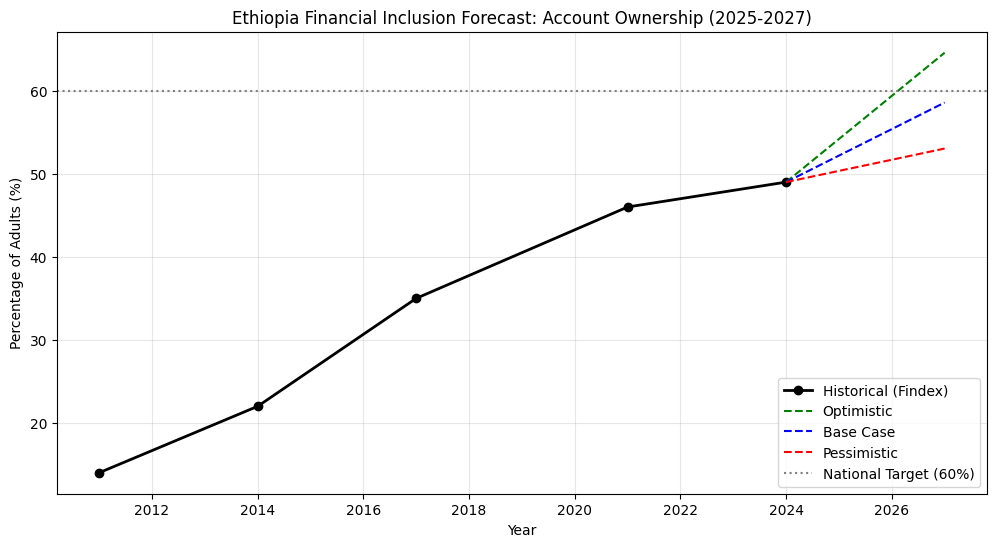

In [7]:
plt.figure(figsize=(12, 6))

# Plot Historical Data
plt.plot(years, values, marker='o', color='black', label='Historical (Findex)', linewidth=2)

# Plot Scenarios
plt.plot([2024] + forecast_years, [49] + forecast_results['Optimistic'], '--', color='green', label='Optimistic')
plt.plot([2024] + forecast_years, [49] + forecast_results['Base'], '--', color='blue', label='Base Case')
plt.plot([2024] + forecast_years, [49] + forecast_results['Pessimistic'], '--', color='red', label='Pessimistic')

plt.title('Ethiopia Financial Inclusion Forecast: Account Ownership (2025-2027)')
plt.ylabel('Percentage of Adults (%)')
plt.xlabel('Year')
plt.axhline(y=60, color='gray', linestyle=':', label='National Target (60%)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../reports/figures/inclusion_forecast_2027.png')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

def generate_inclusion_forecast(indicator_code):
    # 1. Prepare Data
    data = df_obs[df_obs['indicator_code'] == indicator_code].copy()
    data['year'] = data['observation_date'].dt.year
    
    # Historical data points
    X = data[['year']].values
    y = data['value_numeric'].values
    
    # 2. Linear Trend (Baseline)
    model = LinearRegression()
    model.fit(X, y)
    
    # 3. Predict 2025-2027
    future_years = np.array([2025, 2026, 2027]).reshape(-1, 1)
    base_pred = model.predict(future_years)
    
    # 4. Define Scenarios (Quantifying Uncertainty)
    # Optimistic: Trend + High Impact from Fayda ID & M-Pesa expansion (+7%)
    # Pessimistic: Trend - Slow adoption/Infrastructure gap (-3%)
    optimistic = base_pred + 7.0 
    pessimistic = base_pred - 3.0
    
    forecast_df = pd.DataFrame({
        'Year': [2025, 2026, 2027],
        'Base': base_pred,
        'Optimistic': optimistic,
        'Pessimistic': pessimistic
    })
    
    return forecast_df, data

# Run for Account Ownership
forecast_results, history = generate_inclusion_forecast('ACC_OWNERSHIP')
display(forecast_results)